# Sentiment Analysis using two different techniques:
1. VADER (Valence Aware Dictionary and sEntiment Reasoner) - Bag of words approach
2. Roberta Pretrained Model from
3. Huggingface Pipeline

# Step 0. Read in Data and NLTK Basics

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

import nltk

In [4]:
# Read in data
df = pd.read_csv('nyka_top_brands_cosmetics_product_reviews.csv')
print(df.shape)
df = df.head(500)
print(df.shape)

(61284, 18)
(500, 18)


In [5]:
df.head()

,product_id,brand_name,review_id,review_title,review_text,author,review_date,review_rating,is_a_buyer,pro_user,review_label,product_title,mrp,price,product_rating,product_rating_count,product_tags,product_url
0,781070,Olay,16752142,Worth buying 50g one,Works as it claims. Could see the difference f...,Ashton Dsouza,2021-01-23 15:17:18,5.0,True,False,Verified Buyer,Olay Ultra Lightweight Moisturiser: Luminous W...,1999,1599,4.1,43,NaN,https://www.nykaa.com/olay-ultra-lightweight-m...
1,781070,Olay,14682550,Best cream to start ur day,It does what it claims . Best thing is it smoo...,Amrit Neelam,2020-09-07 15:30:42,5.0,True,False,Verified Buyer,Olay Ultra Lightweight Moisturiser: Luminous W...,1999,1599,4.1,43,NaN,https://www.nykaa.com/olay-ultra-lightweight-m...
2,781070,Olay,15618995,perfect for summers dry for winters,I have been using this product for months now....,Sanchi Gupta,2020-11-13 12:24:14,4.0,True,False,Verified Buyer,Olay Ultra Lightweight Moisturiser: Luminous W...,1999,1599,4.1,43,NaN,https://www.nykaa.com/olay-ultra-lightweight-m...
3,781070,Olay,13474509,Not a moisturizer,"i have an oily skin, while this whip acts as a...",Ruchi Shah,2020-06-14 11:56:50,3.0,True,False,Verified Buyer,Olay Ultra Lightweight Moisturiser: Luminous W...,1999,1599,4.1,43,NaN,https://www.nykaa.com/olay-ultra-lightweight-m...
4,781070,Olay,16338982,Average,It's not that good. Please refresh try for oth...,Sukanya Sarkar,2020-12-22 15:24:35,2.0,True,False,Verified Buyer,Olay Ultra Lightweight Moisturiser: Luminous W...,1999,1599,4.1,43,NaN,https://www.nykaa.com/olay-ultra-lightweight-m...


##EDA

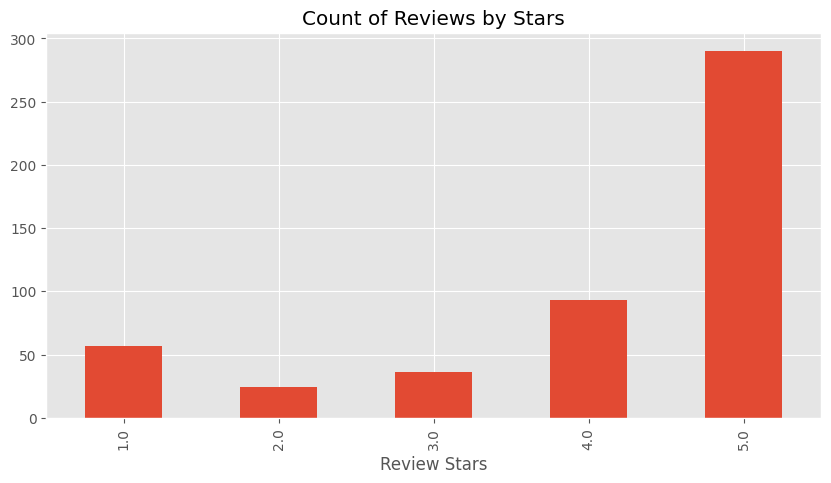

In [6]:
ax = df['review_rating'].value_counts().sort_index() \
    .plot(kind='bar',
          title='Count of Reviews by Stars',
          figsize=(10, 5))
ax.set_xlabel('Review Stars')
plt.show()

## Basic NLTK

In [7]:
example = df['review_text'][50]
print(example)

It applies well and feels good on the skin. It contains texture enhancing super emollients. This cream is just right. Effective without being greasy, as always, and definitely helps with smoothing out the lines and wrinkles.


In [8]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [9]:
tokens = nltk.word_tokenize(example)
tokens[:10]

['It', 'applies', 'well', 'and', 'feels', 'good', 'on', 'the', 'skin', '.']

In [10]:
import nltk
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


True

In [11]:
tagged = nltk.pos_tag(tokens)
tagged[:10]

[('It', 'PRP'),
 ('applies', 'VBZ'),
 ('well', 'RB'),
 ('and', 'CC'),
 ('feels', 'NNS'),
 ('good', 'JJ'),
 ('on', 'IN'),
 ('the', 'DT'),
 ('skin', 'NN'),
 ('.', '.')]

In [12]:
import nltk
nltk.download('maxent_ne_chunker_tab')
nltk.download('words')

[nltk_data] Downloading package maxent_ne_chunker_tab to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping chunkers/maxent_ne_chunker_tab.zip.
[nltk_data] Downloading package words to /root/nltk_data...
[nltk_data]   Unzipping corpora/words.zip.


True

In [13]:
entities = nltk.chunk.ne_chunk(tagged)
entities.pprint()

(S
  It/PRP
  applies/VBZ
  well/RB
  and/CC
  feels/NNS
  good/JJ
  on/IN
  the/DT
  skin/NN
  ./.
  It/PRP
  contains/VBZ
  texture/JJ
  enhancing/VBG
  super/JJ
  emollients/NNS
  ./.
  This/DT
  cream/NN
  is/VBZ
  just/RB
  right/JJ
  ./.
  Effective/VB
  without/IN
  being/VBG
  greasy/JJ
  ,/,
  as/IN
  always/RB
  ,/,
  and/CC
  definitely/RB
  helps/VBZ
  with/IN
  smoothing/VBG
  out/RP
  the/DT
  lines/NNS
  and/CC
  wrinkles/NNS
  ./.)


# Step 1. VADER Seniment Scoring

use NLTK's `SentimentIntensityAnalyzer` to get the neg/neu/pos scores of the text.
- This uses a "bag of words" approach:
    1. Stop words are removed
    2. each word is scored and combined to a total score.

In [14]:
import nltk
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


True

In [15]:
from nltk.sentiment import SentimentIntensityAnalyzer
from tqdm.notebook import tqdm

sia = SentimentIntensityAnalyzer()

In [16]:
sia.polarity_scores('I am so happy!')

{'neg': 0.0, 'neu': 0.318, 'pos': 0.682, 'compound': 0.6468}

In [17]:
sia.polarity_scores('This is the worst thing ever.')

{'neg': 0.451, 'neu': 0.549, 'pos': 0.0, 'compound': -0.6249}

In [18]:
sia.polarity_scores('the product is so bad it makes my skin oily.')

{'neg': 0.333, 'neu': 0.667, 'pos': 0.0, 'compound': -0.6696}

In [19]:
print(example)
sia.polarity_scores(example)

It applies well and feels good on the skin. It contains texture enhancing super emollients. This cream is just right. Effective without being greasy, as always, and definitely helps with smoothing out the lines and wrinkles.


{'neg': 0.0, 'neu': 0.634, 'pos': 0.366, 'compound': 0.946}

In [20]:
# Run the polarity score on the entire dataset
res = {}
for i, row in tqdm(df.iterrows(), total=len(df)):
    text = row['review_text']
    myid = row['review_id']
    res[myid] = sia.polarity_scores(text)

  0%|          | 0/500 [00:00<?, ?it/s]

In [21]:
vaders = pd.DataFrame(res).T
vaders = vaders.reset_index().rename(columns={'index': 'review_id'})
vaders = vaders.merge(df, how='left')

In [22]:
# Now we have sentiment score and metadata
vaders.head()

,review_id,neg,neu,pos,compound,product_id,brand_name,review_title,review_text,author,...,is_a_buyer,pro_user,review_label,product_title,mrp,price,product_rating,product_rating_count,product_tags,product_url
0,16752142,0.000,0.819,0.181,0.6369,781070,Olay,Worth buying 50g one,Works as it claims. Could see the difference f...,Ashton Dsouza,...,True,False,Verified Buyer,Olay Ultra Lightweight Moisturiser: Luminous W...,1999,1599,4.1,43,NaN,https://www.nykaa.com/olay-ultra-lightweight-m...
1,14682550,0.000,0.682,0.318,0.7906,781070,Olay,Best cream to start ur day,It does what it claims . Best thing is it smoo...,Amrit Neelam,...,True,False,Verified Buyer,Olay Ultra Lightweight Moisturiser: Luminous W...,1999,1599,4.1,43,NaN,https://www.nykaa.com/olay-ultra-lightweight-m...
2,15618995,0.000,0.881,0.119,0.4404,781070,Olay,perfect for summers dry for winters,I have been using this product for months now....,Sanchi Gupta,...,True,False,Verified Buyer,Olay Ultra Lightweight Moisturiser: Luminous W...,1999,1599,4.1,43,NaN,https://www.nykaa.com/olay-ultra-lightweight-m...
3,13474509,0.048,0.891,0.061,0.1408,781070,Olay,Not a moisturizer,"i have an oily skin, while this whip acts as a...",Ruchi Shah,...,True,False,Verified Buyer,Olay Ultra Lightweight Moisturiser: Luminous W...,1999,1599,4.1,43,NaN,https://www.nykaa.com/olay-ultra-lightweight-m...
4,16338982,0.353,0.647,0.000,-0.5216,781070,Olay,Average,It's not that good. Please refresh try for oth...,Sukanya Sarkar,...,True,False,Verified Buyer,Olay Ultra Lightweight Moisturiser: Luminous W...,1999,1599,4.1,43,NaN,https://www.nykaa.com/olay-ultra-lightweight-m...


## Plot VADER results

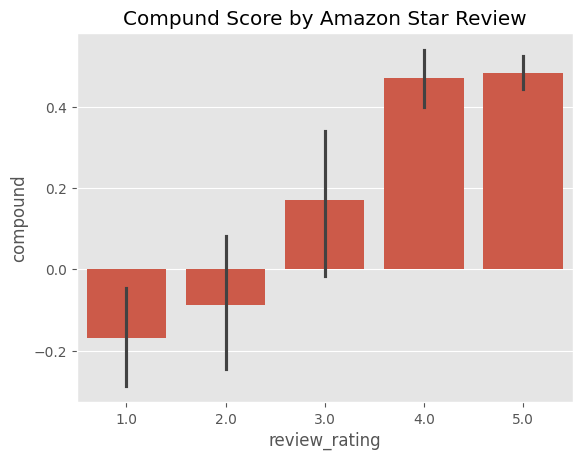

In [23]:
ax = sns.barplot(data=vaders, x='review_rating', y='compound')
ax.set_title('Compund Score by Amazon Star Review')
plt.show()

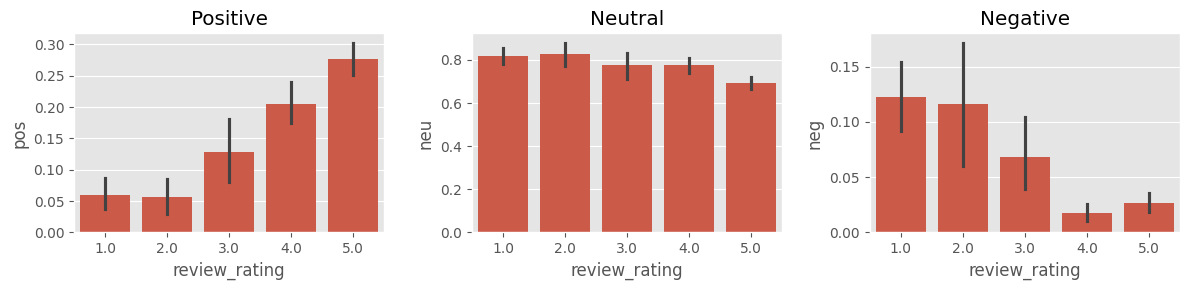

In [24]:
fig, axs = plt.subplots(1, 3, figsize=(12, 3))
sns.barplot(data=vaders, x='review_rating', y='pos', ax=axs[0])
sns.barplot(data=vaders, x='review_rating', y='neu', ax=axs[1])
sns.barplot(data=vaders, x='review_rating', y='neg', ax=axs[2])
axs[0].set_title('Positive')
axs[1].set_title('Neutral')
axs[2].set_title('Negative')
plt.tight_layout()
plt.show()

# Step 3. Roberta Pretrained Model

- Use a model trained of a large corpus of data.
- Transformer model accounts for the words but also the context related to other words.

In [25]:
from transformers import AutoTokenizer
from transformers import AutoModelForSequenceClassification
from scipy.special import softmax

In [26]:
MODEL = f"cardiffnlp/twitter-roberta-base-sentiment"
tokenizer = AutoTokenizer.from_pretrained(MODEL)
model = AutoModelForSequenceClassification.from_pretrained(MODEL)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/747 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

In [27]:
# VADER results on example
print(example)
sia.polarity_scores(example)

It applies well and feels good on the skin. It contains texture enhancing super emollients. This cream is just right. Effective without being greasy, as always, and definitely helps with smoothing out the lines and wrinkles.


{'neg': 0.0, 'neu': 0.634, 'pos': 0.366, 'compound': 0.946}

In [28]:
# Run for Roberta Model
encoded_text = tokenizer(example, return_tensors='pt') #encode the tewt so the machine will undrestand it
output = model(**encoded_text) #use the model on it
scores = output[0][0].detach().numpy() #transfer it into numpy
scores = softmax(scores)
scores_dict = {
    'roberta_neg' : scores[0],
    'roberta_neu' : scores[1],
    'roberta_pos' : scores[2]
}
print(scores_dict)

{'roberta_neg': np.float32(0.0020061391), 'roberta_neu': np.float32(0.03842665), 'roberta_pos': np.float32(0.95956725)}


In [29]:
#run the model for the whole dataset
def polarity_scores_roberta(example):
    encoded_text = tokenizer(example, return_tensors='pt')
    output = model(**encoded_text)
    scores = output[0][0].detach().numpy()
    scores = softmax(scores)
    scores_dict = {
        'roberta_neg' : scores[0],
        'roberta_neu' : scores[1],
        'roberta_pos' : scores[2]
    }
    return scores_dict

In [30]:
res = {}
for i, row in tqdm(df.iterrows(), total=len(df)):
        text = row['review_text']
        myid = row['review_id']
        vader_result = sia.polarity_scores(text)
        vader_result_rename = {}

        roberta_result = polarity_scores_roberta(text)
        break

  0%|          | 0/500 [00:00<?, ?it/s]

In [31]:
vader_result

{'neg': 0.0, 'neu': 0.819, 'pos': 0.181, 'compound': 0.6369}

In [32]:
roberta_result

{'roberta_neg': np.float32(0.0075611235),
 'roberta_neu': np.float32(0.23939888),
 'roberta_pos': np.float32(0.75304)}

In [33]:
res = {}
for i, row in tqdm(df.iterrows(), total=len(df)):
    try:
        text = row['review_text']
        myid = row['review_id']
        vader_result = sia.polarity_scores(text)
        vader_result_rename = {}
        for key, value in vader_result.items():
            vader_result_rename[f"vader_{key}"] = value
        roberta_result = polarity_scores_roberta(text)
        both = {**vader_result_rename, **roberta_result}
        res[myid] = both
    except RuntimeError:
        print(f'Broke for id {myid}')

  0%|          | 0/500 [00:00<?, ?it/s]

In [34]:
results_df = pd.DataFrame(res).T
results_df = results_df.reset_index().rename(columns={'index': 'review_id'})
results_df = results_df.merge(df, how='left')

In [35]:
results_df.head()

,review_id,vader_neg,vader_neu,vader_pos,vader_compound,roberta_neg,roberta_neu,roberta_pos,product_id,brand_name,...,is_a_buyer,pro_user,review_label,product_title,mrp,price,product_rating,product_rating_count,product_tags,product_url
0,16752142,0.000,0.819,0.181,0.6369,0.007561,0.239399,0.753040,781070,Olay,...,True,False,Verified Buyer,Olay Ultra Lightweight Moisturiser: Luminous W...,1999,1599,4.1,43,NaN,https://www.nykaa.com/olay-ultra-lightweight-m...
1,14682550,0.000,0.682,0.318,0.7906,0.002643,0.033572,0.963785,781070,Olay,...,True,False,Verified Buyer,Olay Ultra Lightweight Moisturiser: Luminous W...,1999,1599,4.1,43,NaN,https://www.nykaa.com/olay-ultra-lightweight-m...
2,15618995,0.000,0.881,0.119,0.4404,0.037624,0.167966,0.794409,781070,Olay,...,True,False,Verified Buyer,Olay Ultra Lightweight Moisturiser: Luminous W...,1999,1599,4.1,43,NaN,https://www.nykaa.com/olay-ultra-lightweight-m...
3,13474509,0.048,0.891,0.061,0.1408,0.768754,0.202071,0.029175,781070,Olay,...,True,False,Verified Buyer,Olay Ultra Lightweight Moisturiser: Luminous W...,1999,1599,4.1,43,NaN,https://www.nykaa.com/olay-ultra-lightweight-m...
4,16338982,0.353,0.647,0.000,-0.5216,0.885471,0.102478,0.012051,781070,Olay,...,True,False,Verified Buyer,Olay Ultra Lightweight Moisturiser: Luminous W...,1999,1599,4.1,43,NaN,https://www.nykaa.com/olay-ultra-lightweight-m...


## Compare Scores between models

In [36]:
results_df.columns

Index(['review_id', 'vader_neg', 'vader_neu', 'vader_pos', 'vader_compound',
       'roberta_neg', 'roberta_neu', 'roberta_pos', 'product_id', 'brand_name',
       'review_title', 'review_text', 'author', 'review_date', 'review_rating',
       'is_a_buyer', 'pro_user', 'review_label', 'product_title', 'mrp',
       'price', 'product_rating', 'product_rating_count', 'product_tags',
       'product_url'],
      dtype='object')

# Step 3. Combine and compare

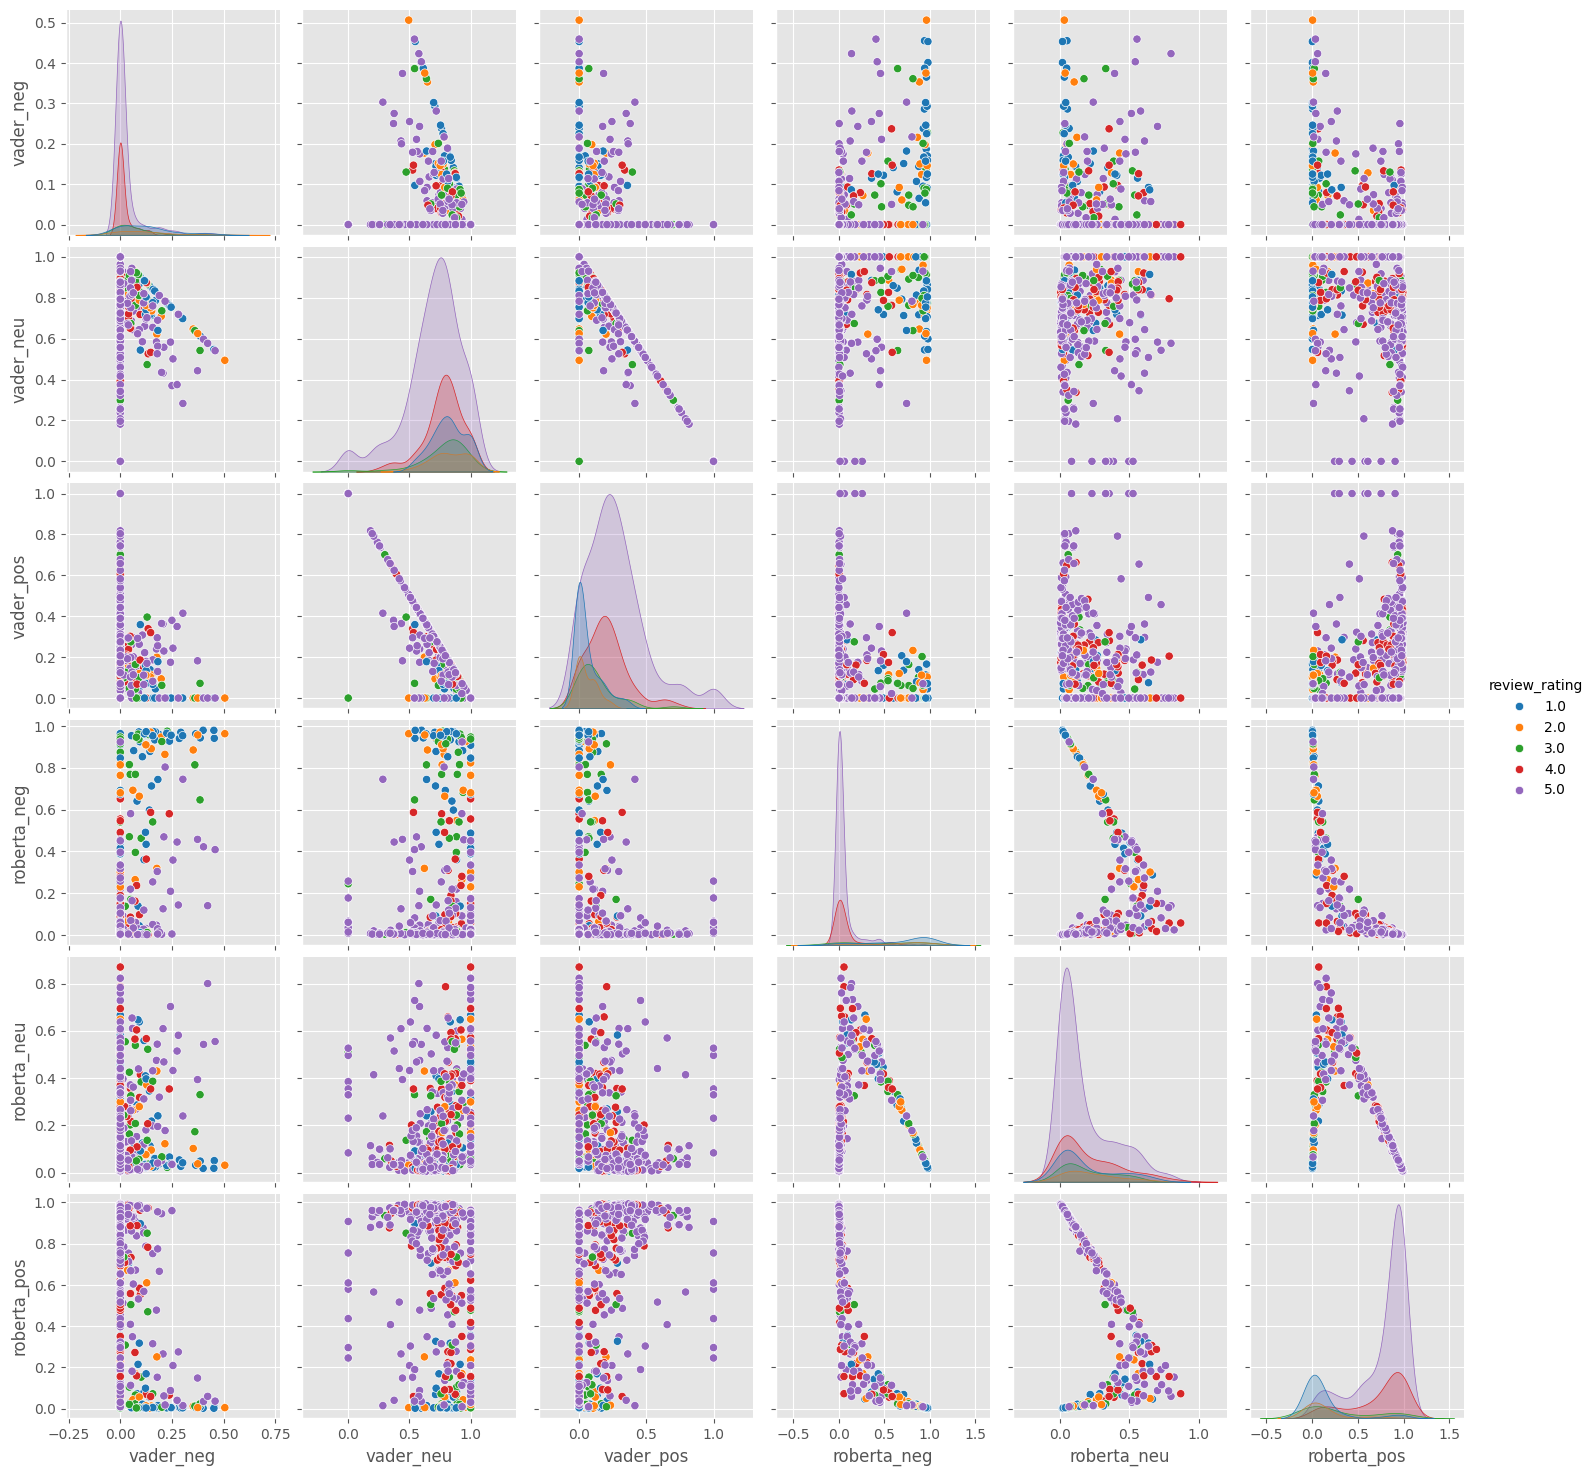

In [37]:
sns.pairplot(data=results_df,
             vars=['vader_neg', 'vader_neu', 'vader_pos',
                  'roberta_neg', 'roberta_neu', 'roberta_pos'],
            hue='review_rating',
            palette='tab10')
plt.show()

# Step 4: Review Examples:

- Positive 1-Star and Negative 5-Star Reviews

Lets look at some examples where the model scoring and review score differ the most.

In [38]:
results_df.query('review_rating == 1') \
    .sort_values('roberta_pos', ascending=False)['review_text'].values[2]

'It is excellent for dark circles and lines.'

In [39]:
results_df.query('review_rating == 1') \
    .sort_values('vader_pos', ascending=False)['review_text'].values[0]

'At this price it is good BB cream but contains paraben. Gives visible flawless look also skin looks radiance. Nice product. However, not paraben free.'

In [40]:
# nevative sentiment 5-Star view

In [41]:
results_df.query('review_rating == 5') \
    .sort_values('roberta_neg', ascending=False)['review_text'].values[1]

'Had high expectations. But not worked well on me.'

In [42]:
results_df.query('review_rating == 5') \
    .sort_values('vader_neg', ascending=False)['review_text'].values[1]

'No visible changes overnight.'

In [43]:
from sklearn.metrics import accuracy_score

# Prepare data for accuracy calculation
vader_predictions = vaders['compound'].apply(lambda score: 1 if score >= 0 else 0)  # Positive sentiment if compound score >= 0
roberta_predictions = results_df['roberta_pos'].apply(lambda score: 1 if score >= 0.5 else 0)  # Positive sentiment if roberta_pos score >= 0.5
true_labels = df['review_rating'].apply(lambda rating: 1 if rating >= 3 else 0)  # Positive sentiment if review rating >= 3

# Calculate accuracy
vader_accuracy = accuracy_score(true_labels, vader_predictions)
roberta_accuracy = accuracy_score(true_labels, roberta_predictions)

# Print results
print(f"VADER Accuracy: {vader_accuracy}")
print(f"Roberta Accuracy: {roberta_accuracy}")

VADER Accuracy: 0.86
Roberta Accuracy: 0.802


VADER achieved 86% accuracy in our sentiment analysis, outperforming Roberta's 80.2%. VADER's lexicon-based approach proved more effective for this product review dataset, offering higher reliability for overall sentiment prediction.

# The Transformers Pipeline
- Quick & easy way to run sentiment predictions

In [44]:
from transformers import pipeline

sent_pipeline = pipeline("sentiment-analysis")

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f (https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english).
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

Device set to use cpu


In [45]:
sent_pipeline('I love this product!')

[{'label': 'POSITIVE', 'score': 0.9998855590820312}]

In [46]:
sent_pipeline('it makes my skin oily ')

[{'label': 'NEGATIVE', 'score': 0.8892971277236938}]

In [47]:
sent_pipeline('booo')

[{'label': 'NEGATIVE', 'score': 0.9936267137527466}]

In [48]:
sent_pipeline('the product is expensive ')

[{'label': 'NEGATIVE', 'score': 0.999457061290741}]